# Tests de robustesse : sensibilite au bruit et resistance a l'imputation

Ce notebook evalue la fragilite du modele `depression_classifier` face a deux types de perturbations :

1. **Bruit sur les features** : on corrompt les valeurs numeriques d'une colonne et on mesure l'impact sur le F1-score.
2. **Valeurs manquantes** : on introduit des NaN artificiels a des taux croissants, on les impute, puis on mesure si le modele resiste.

## 1. Imports et chargement des artefacts

On charge le modele et l'imputer depuis leur emplacement fixe (chemin relatif au script), ainsi que le dataset complet.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import joblib
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt

PROJECT_DIR  = Path("atelier-information-et-documentation-main")
CSV_PATH     = PROJECT_DIR / "student_lifestyle_100k.csv"
MODEL_PATH   = PROJECT_DIR / "depression_classifier.joblib"
IMPUTER_PATH = PROJECT_DIR / "imputer.joblib"

model   = joblib.load(MODEL_PATH)
imputer = joblib.load(IMPUTER_PATH)

df = pd.read_csv(CSV_PATH)
print(f"Dataset charge : {df.shape[0]:,} lignes x {df.shape[1]} colonnes")

Dataset charge : 100,000 lignes x 11 colonnes


C:\Users\yoann\AppData\Roaming\Python\Python313\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator OneHotEncoder from version 1.7.0 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\yoann\AppData\Roaming\Python\Python313\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator FunctionTransformer from version 1.7.0 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\yoann\AppData\Roaming\Python\Python313\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator ColumnTransformer from ver

In [2]:
TARGET   = "Depression"
X        = df.drop(columns=[TARGET, "Student_ID"], errors="ignore")
y        = df[TARGET].astype(int)
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()

print("Colonnes numeriques :", num_cols)

Colonnes numeriques : ['Age', 'CGPA', 'Sleep_Duration', 'Study_Hours', 'Social_Media_Hours', 'Physical_Activity', 'Stress_Level']


## 2. Selection des 3 features les plus correlees avec la cible

On calcule la correlation entre chaque feature numerique et `Depression` pour cibler les tests de bruit sur les variables les plus influentes.

In [3]:
corr = (
    df[num_cols + [TARGET]]
    .assign(**{TARGET: df[TARGET].astype(int)})
    .corr()[TARGET]
    .drop(TARGET)
    .abs()
    .sort_values(ascending=False)
)

top3 = corr.head(3).index.tolist()
print("Top 3 features correlees avec Depression :")
print(corr.head(5).to_string())

Top 3 features correlees avec Depression :
CGPA                  0.178971
Stress_Level          0.075866
Sleep_Duration        0.057529
Social_Media_Hours    0.016771
Study_Hours           0.015932


## 3. Score de reference (baseline)

On calcule le F1-score sur les donnees propres (sans perturbation).
Toutes les variations suivantes seront exprimees en pourcentage de variation par rapport a ce score.

In [4]:
f1_base = f1_score(y, model.predict(X))
print(f"F1 baseline (donnees propres) : {f1_base:.4f}")

F1 baseline (donnees propres) : 0.2677


## 4. Sensibilite au bruit

Pour chaque feature du top 3, on ajoute un bruit gaussien proportionnel a son ecart-type, a des niveaux croissants : 1%, 3%, 5%, 10%, 15%, 20%.

In [5]:
rng = np.random.default_rng(42)  # graine fixe pour la reproductibilite

def noise_variation(feature, noise_pct):
    X_noisy = X.copy()
    std = X_noisy[feature].std()
    X_noisy[feature] += rng.normal(0, std * noise_pct / 100, size=len(X_noisy))
    f1 = f1_score(y, model.predict(X_noisy))
    return 100 * (f1 - f1_base) / f1_base

intensities = np.array([1, 3, 5, 10, 15, 20])
markers     = ["o-", "s-", "^-"]

results_noise = {}
for feat in top3:
    results_noise[feat] = [noise_variation(feat, n) for n in intensities]
    print(f"{feat} : {[f'{v:+.2f}%' for v in results_noise[feat]]}")

CGPA : ['-0.04%', '+0.03%', '+0.01%', '+0.05%', '-0.14%', '-0.91%']
Stress_Level : ['-0.04%', '+0.04%', '-0.19%', '+0.02%', '+0.15%', '-0.05%']
Sleep_Duration : ['-0.05%', '-0.03%', '-0.03%', '+0.04%', '+0.06%', '-0.07%']


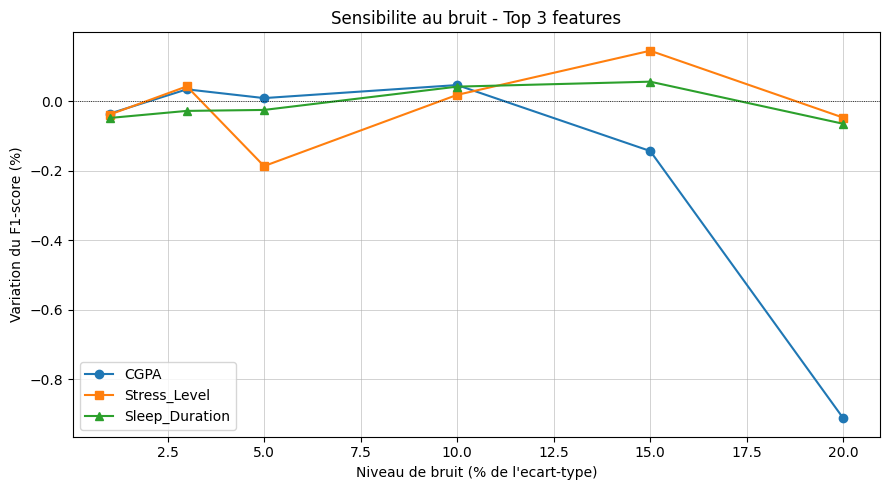

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))

for feat, marker in zip(top3, markers):
    ax.plot(intensities, results_noise[feat], marker, label=feat)

ax.axhline(0, color="black", linewidth=0.6, linestyle=":")
ax.set_title("Sensibilite au bruit - Top 3 features")
ax.set_xlabel("Niveau de bruit (% de l'ecart-type)")
ax.set_ylabel("Variation du F1-score (%)")
ax.legend()
ax.grid(True, linewidth=0.4)
plt.tight_layout()
plt.show()

## 5. Resistance a l'imputation

On simule des donnees manquantes en remplacant aleatoirement des valeurs numeriques par `NaN`, a des taux croissants (1%, 5%, 10%, 20%, 30%), puis on applique l'imputer avant de predire.

In [7]:
nan_rates     = [0.01, 0.05, 0.10, 0.20, 0.30]
f1_variations = []

for rate in nan_rates:
    X_missing = X.copy()
    for col in num_cols:
        mask = rng.random(len(X_missing)) < rate
        X_missing.loc[mask, col] = np.nan

    X_imputed          = X_missing.copy()
    X_imputed[num_cols] = imputer.transform(X_missing[num_cols])

    f1  = f1_score(y, model.predict(X_imputed))
    var = 100 * (f1 - f1_base) / f1_base
    f1_variations.append(var)
    print(f"Taux NaN {rate*100:4.0f}% : F1 = {f1:.4f}  (variation : {var:+.3f}%)")

Taux NaN    1% : F1 = 0.2666  (variation : -0.409%)
Taux NaN    5% : F1 = 0.2661  (variation : -0.613%)
Taux NaN   10% : F1 = 0.2640  (variation : -1.376%)
Taux NaN   20% : F1 = 0.2564  (variation : -4.213%)
Taux NaN   30% : F1 = 0.2500  (variation : -6.635%)


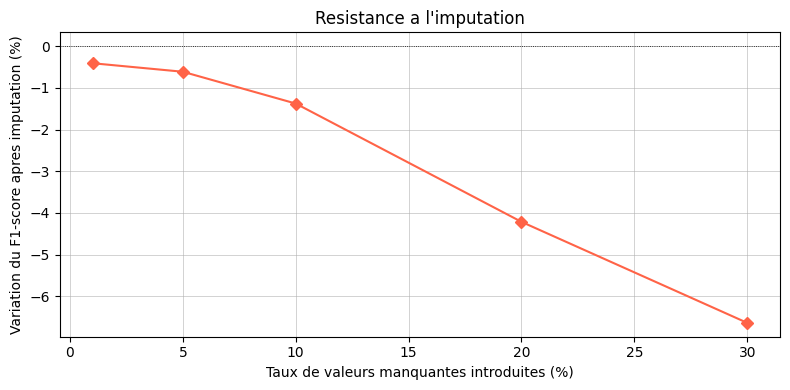

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot([r * 100 for r in nan_rates], f1_variations, "D-", color="tomato")
ax.axhline(0, color="black", linewidth=0.6, linestyle=":")
ax.set_title("Resistance a l'imputation")
ax.set_xlabel("Taux de valeurs manquantes introduites (%)")
ax.set_ylabel("Variation du F1-score apres imputation (%)")
ax.grid(True, linewidth=0.4)
plt.tight_layout()
plt.show()

## 6. Synthese

Le tableau ci-dessous recapitule les variations de F1-score en fonction du taux de NaN imputes.

In [9]:
synthese = pd.DataFrame({
    "Taux NaN (%)": [r * 100 for r in nan_rates],
    "Variation F1 (%)": [f"{v:+.3f}" for v in f1_variations]
})
print(synthese.to_string(index=False))

 Taux NaN (%) Variation F1 (%)
          1.0           -0.409
          5.0           -0.613
         10.0           -1.376
         20.0           -4.213
         30.0           -6.635
